In [4]:
import pandas as pd
import numpy as np
from pybads import BADS
import os
import pathlib
import sys
base_path = pathlib.Path().resolve().parents[1]
PROJECT_ROOT = pathlib.Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from math_analysis.potencial import get_expressions
from helpers.sim_helpers_fit import simulate_path, make_drift

In [5]:
df = pd.read_csv('./datasets/df_filtered.csv', sep = ';')
# Count rows per subject
subject_counts = df['subject'].value_counts()
print("Number of rows per subject:")
print(subject_counts)
# Calculate percentage of rows with timepoint_4 > 5 for each subject
timepoint_high_pct = {}
for subject in df['subject'].unique():
    subject_df = df[df['subject'] == subject]
    high_timepoint = subject_df[subject_df['timepoint_4'] > 7.5].shape[0]
    total = subject_df.shape[0]
    timepoint_high_pct[subject] = (high_timepoint / total) * 100

# Convert to Series for better display
timepoint_high_series = pd.Series(timepoint_high_pct)
print("\nPercentage of rows with timepoint_4 > 7.5s by subject:")
print(timepoint_high_series)
# Summary statistics
print("\nSummary statistics:")
print(f"Total subjects: {len(subject_counts)}")
print(f"Average rows per subject: {subject_counts.mean():.2f}")
print(f"Minimum rows per subject: {subject_counts.min()}")
print(f"Maximum rows per subject: {subject_counts.max()}")


FileNotFoundError: [Errno 2] No such file or directory: './datasets/df_filtered.csv'

In [6]:
print(df['ttype_c'].value_counts()/ len(df) * 100)

ttype_c
DS     34.168716
DM     28.145250
DL     23.834359
VG     11.247690
SIL     2.603984
Name: count, dtype: float64


In [4]:
subjects = ['A86']
df = df[df['subject'].isin(subjects)]
df[df['timepoint_4']>5].shape[0]/df.shape[0] *100
df = df[df['timepoint_4']<=5]
# df = df[:10000]
df.shape

(81612, 40)

In [119]:

print(df.columns)

Index(['Unnamed: 0', 'subject', 'date', 'stage', 'substage', 'batch', 'trial',
       'session', 'total_trials', 'trial_type', 'ttype_n', 'ttype_c',
       'stimd_n', 'stimd_c', 'y', 'x', 'x_c', 'r_c', 'delay_abs', 'delay_rw',
       'trial_result', 'chance', 'correction_bias', 'trial_length',
       'STATE_Start_task_START', 'STATE_Fixation1_START',
       'STATE_Fixation2_START', 'STATE_Fixation3_START',
       'STATE_Fixation1_START_last', 'STATE_Fixation2_START_last',
       'STATE_Fixation3_END', 'STATE_Fixation3_START_last',
       'STATE_Response_window_START', 'STATE_Response_window_END',
       'STATE_Exit_START', 'timepoint_1', 'timepoint_2', 'timepoint_3',
       'timepoint_4'],
      dtype='object')


In [120]:
def get_onset_offset(stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4):
    """
    Devuelve los posibles valores de onset y el valor de offset
    según el tipo de trial.
    """
    if stim_dur == 'VG':
        onset = 0
        offset = timepoint_4

    elif stim_dur == 'SS':
        if delay_dur == 'DS':
            onset = timepoint_2
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = timepoint_1
            offset = timepoint_2
        elif delay_dur == 'DL':
            onset = 0
            offset = timepoint_1

    elif stim_dur == 'SM':
        if delay_dur == 'DS':
            onset = timepoint_1
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = 0
            offset = timepoint_2

    elif stim_dur == 'SL':
        onset = 0
        offset = timepoint_3
    
    elif stim_dur == 'SIL':
        onset = 0
        offset = 0

    else:
        raise ValueError(f"stim_dur desconocido: {stim_dur}")

    return onset, offset


In [8]:
drift = make_drift()
from tqdm import tqdm

def objective_function(params):
    """
    Objective function to minimize.
    """

    sse = 0

    for row in tqdm(df.itertuples(), total=len(df), desc="Evaluating rows"):
        onset, offset = get_onset_offset(stim_dur = row.stimd_c ,delay_dur = row.ttype_c, timepoint_1 = row.timepoint_1,timepoint_2 = row.timepoint_2,timepoint_3 = row.timepoint_3,timepoint_4 = row.timepoint_4)
        U_int_params = {
            'offset': row.timepoint_4,
            'amplitude': params[6],
            'baseline': params[7],
            'onset': params[8],
        }

        S_params = {
            'offset': offset,
            'onset': onset, 
            'd': params[5],
            'amplitude': params[4],
        }
        U_ext_params = {
            'offset': offset,
            'onset': onset,
            'amplitude': params[9]
        }

        s_params = {
            'sL': params[0],
            'sC': params[1],
            'sR': params[2],
        }
        side = row.x_c if row.ttype_c != 'SIL' else 'SIL'
        sim_choice = simulate_path(side = side, S_params = S_params, U_int_params=U_int_params,U_ext_params=U_ext_params, s_params=s_params, drift_fn = drift, noise_amp=params[3], Tmax = row.timepoint_4, dt = 0.1/40)
        
        if sim_choice != row.r_c:
            sse += 1  
   
    
    return (1 - (sse / len(df)) )

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in sqrt
  return (select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,2*I0 + 2*R - 2*R_I,2/sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan) - 1, R - select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,(I0 + R - R_I)**2,sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan), R_I - select([less(R + 0.333333333333333, 0),less_equal(R + 0.333333333333333, 1),True], [0,(R + 0.333333333333333)**2,sqrt(4*R - 1.66666666666667)], default=nan),)


In [122]:
x0 = np.array([
    0.5,   # sL
    0.5,   # sC
    0.5,   # sR
    0.75,  # sigma (ruido mínimo razonable)
    0.1,   # A_stim
    0.5,   # Delta_stim
    2.0,   # A_ui
    -1.0,   # B_ui
    0.0,   # t_on
    0.0    # A_u_ext
])

lb = np.array([
    -1.0,   # sL
    -1.0,   # sC
    -1.0,   # sR
    0.01,  # sigma (ruido mínimo razonable)
    0.0,   # A_stim
    0.0,   # Delta_stim
    0.0,   # A_ui
    -5,   # B_ui
    0.0,   # t_on
    0.0    # A_u_ext
])

ub = np.array([
    2.0,   # sL
    2.0,   # sC
    2.0,   # sR
    2.0,   # sigma
    2.0,   # A_stim
    1,   # Delta_stim  (por las notas: marcado como (0, 0.1))
    10.0,  # A_ui         (por las notas: entre 0 y 10)
    2,  # B_ui         (por las notas: entre 0 y 10)
    2.0,   # t_on         (por las notas: hasta ~2s)
    10.0   # A_u_ext      (por las notas: entre 0 y 10)
])

plausible_lower_bounds = np.array([
    -0.75,  # sL
    -0.75,  # sC
    -0.75,  # sR
    0.4,   # sigma
    0.5,   # A_stim
    0.1,  # Delta_stim
    1,   # A_ui
    -3,   # B_ui
    0.0,   # t_on
    0    # A_u_ext
])
plausible_upper_bounds = np.array([
    0.75,  # sL
    0.75,  # sC
    0.75,  # sR
    1,   # sigma
    1.25,   # A_stim
    0.8,  # Delta_stim
    5,   # A_ui
    0,   # B_ui
    0.5,   # t_on
    5    # A_u_ext
])



options = {
    "uncertainty_handling": True,
    "max_fun_evals": 5000,
    # "D": 1ç0,  # Number of parameters
    # "noise_final_samples": 100
}

In [123]:
# params = np.array([
#     sL    ,     # 0
#     sC    ,     # 1
#     sR    ,     # 2
#     sigma ,     # 3
#     A_stim,     # 4
#     Delta_stim, # 5
#     A_ui,       # 6
#     B_ui,       # 7
#     t_on,       # 8
#     A_u_ext,    # 9
#])

In [6]:
objective_function(x0)

NameError: name 'objective_function' is not defined

In [33]:
bads = BADS(
    objective_function, x0, lb, ub, plausible_lower_bounds, plausible_upper_bounds, options=options, 
)
optimize_result = bads.optimize()

NameError: name 'D' is not defined

In [124]:
param_names = [
    "sL", "sC", "sR", "sigma", "A_stim",
    "Delta_stim", "A_ui", "B_ui", "t_on", "A_u_ext"
]

param_values = [
    -8.30118656e-02, -4.95907724e-01, -9.71766114e-02,  4.12979053e-02,
     1.14936913e+00,  8.82939982e-01,  1.85440636e+00, -5.74825644e-01,
     1.08360234e-01,  3.70497704e-04
]

opt_value = 0.0036000000000000255

print("Parámetros óptimos:\n")
print(f"{'Parámetro':<12} {'Valor':>15}")
print("-" * 30)
for name, value in zip(param_names, param_values):
    print(f"{name:<12} {value:>15.10f}")

print("\nValor óptimo de la función objetivo:")
print(f"{opt_value:.16f}")


Parámetros óptimos:

Parámetro              Valor
------------------------------
sL             -0.0830118656
sC             -0.4959077240
sR             -0.0971766114
sigma           0.0412979053
A_stim          1.1493691300
Delta_stim      0.8829399820
A_ui            1.8544063600
B_ui           -0.5748256440
t_on            0.1083602340
A_u_ext         0.0003704977

Valor óptimo de la función objetivo:
0.0036000000000000


In [1]:
param_names = [
    "sL", "sC", "sR", "sigma", "A_stim",
    "Delta_stim", "A_ui", "B_ui", "t_on", "A_u_ext"
]

# Valores óptimos para A92
params_A92 = [
    -8.30118656e-02, -4.95907724e-01, -9.71766114e-02,  4.12979053e-02,
     1.14936913e+00,  8.82939982e-01,  1.85440636e+00, -5.74825644e-01,
     1.08360234e-01,  3.70497704e-04
]

# Valores óptimos para A86
params_A86 = [
    -5.74445477e-02,  3.74356649e-02,  1.93385239e-02,  1.08410825e-02,
     9.32344170e-01,  5.65683331e-01,  2.16965523e+00, -8.70846568e-01,
     1.52865134e-02,  7.14531658e-04
]

print("Parámetros óptimos:\n")
print(f"{'Parámetro':<12} {'A92':>15} {'A86':>15}")
print("-" * 45)
for name, val_A92, val_A86 in zip(param_names, params_A92, params_A86):
    print(f"{name:<12} {val_A92:>15.10f} {val_A86:>15.10f}")


Parámetros óptimos:

Parámetro                A92             A86
---------------------------------------------
sL             -0.0830118656   -0.0574445477
sC             -0.4959077240    0.0374356649
sR             -0.0971766114    0.0193385239
sigma           0.0412979053    0.0108410825
A_stim          1.1493691300    0.9323441700
Delta_stim      0.8829399820    0.5656833310
A_ui            1.8544063600    2.1696552300
B_ui           -0.5748256440   -0.8708465680
t_on            0.1083602340    0.0152865134
A_u_ext         0.0003704977    0.0007145317


In [137]:
param_names = [
    "sL", "sC", "sR", "sigma", "A_stim",
    "Delta_stim", "A_ui", "B_ui", "t_on", "A_u_ext"
]

# A92
params_A92 = [
    -8.30118656e-02, -4.95907724e-01, -9.71766114e-02,  4.12979053e-02,
     1.14936913e+00,  8.82939982e-01,  1.85440636e+00, -5.74825644e-01,
     1.08360234e-01,  3.70497704e-04
]

# A86
params_A86 = [
    -5.74445477e-02,  3.74356649e-02,  1.93385239e-02,  1.08410825e-02,
     9.32344170e-01,  5.65683331e-01,  2.16965523e+00, -8.70846568e-01,
     1.52865134e-02,  7.14531658e-04
]

# A92b
params_A92b = [
    -0.34073166, -0.30058414, -0.43264523,  0.01129881,
     1.94887388,  0.01402164,  0.87198209, -0.05377584,
     0.0039844,   0.11306175
]

# A92_full
params_A92_full = [
    -0.34372392, -0.63417981, -0.28115995,  0.06505975,
     1.1597604,   0.4195675,   2.43914035, -2.68339947,
     0.33322714,  2.13479708
]

params_A86_full = [-0.66689372, -0.35273266, -0.72095346,  0.04602837,  1.052511,    0.27746468,
  2.81862259, -2.66441345,  0.41493271,  0.80180825]

# Imprimir tabla
print("Parámetros óptimos:\n")
print(f"{'Parámetro':<12} {'A92':>15} {'A86':>15} {'A92b':>15} {'A92_full':>15} {'A86_full':>15}")
print("-" * 100)
for name, val_A92, val_A86, val_A92b, val_A92_full, val_A86_full in zip(
    param_names, params_A92, params_A86, params_A92b, params_A92_full, params_A86_full):
    print(f"{name:<12} {val_A92:>15.10f} {val_A86:>15.10f} {val_A92b:>15.10f} {val_A92_full:>15.10f} {val_A86_full:>15.10f}")


Parámetros óptimos:

Parámetro                A92             A86            A92b        A92_full        A86_full
----------------------------------------------------------------------------------------------------
sL             -0.0830118656   -0.0574445477   -0.3407316600   -0.3437239200   -0.6668937200
sC             -0.4959077240    0.0374356649   -0.3005841400   -0.6341798100   -0.3527326600
sR             -0.0971766114    0.0193385239   -0.4326452300   -0.2811599500   -0.7209534600
sigma           0.0412979053    0.0108410825    0.0112988100    0.0650597500    0.0460283700
A_stim          1.1493691300    0.9323441700    1.9488738800    1.1597604000    1.0525110000
Delta_stim      0.8829399820    0.5656833310    0.0140216400    0.4195675000    0.2774646800
A_ui            1.8544063600    2.1696552300    0.8719820900    2.4391403500    2.8186225900
B_ui           -0.5748256440   -0.8708465680   -0.0537758400   -2.6833994700   -2.6644134500
t_on            0.1083602340    0.0152865

In [9]:
import pickle

# Ruta al archivo
with open("./datasets/result_A92.pkl", "rb") as f:
    result = pickle.load(f)

# Mostrar tiempo total
print(f"⏱️ Tiempo total de optimización: {result.total_time/60/60:.2f} horas")
print(result.fsd)
print(result.fval*100)
print(result.x)

⏱️ Tiempo total de optimización: 1.22 horas
5.6272666111514125e-05
0.9824059407626928
[-0.48740935 -0.17685424 -0.25951704  0.05933022  0.86059296  0.30978583
  3.01964835 -3.24663093  0.52779546  2.17889488]


In [9]:
from sympy import pprint
# --- Simulación paralelizable por fila ---
values = {
        "tau": 0.1,
        "c": 1,
        "g": 1,
        "s0": 1,
        "IL": 1/3,
        "IC": 1,
        "IR": 1,
        "I_I": 1/3,
        "sL": 0,
        "sC": 0,
        "sR": 0,
    }
# Suponiendo que ya has llamado a tu función get_expressions con el diccionario `values`
U_sim, F1_sim, F2_sim, H_sim = get_expressions(values, type='symbolic', substituted_S=False)

# Imprime las expresiones simbólicas de F1 y F2 de forma bonita
print("📘 F1 simplificada:")
pprint(F1_sim, use_unicode=True)

print("\n📗 F2 simplificada:")
pprint(F2_sim, use_unicode=True)

Piecewise((0, x < 0), (x**2, x <= 1), (2*sqrt(x - 3/4), True))
R: 0.25 R_I: 0.34027777777777735 I0: 0.5902777777777773


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in sqrt
  return (select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,2*I0 + 2*R - 2*R_I,2/sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan) - 1, R - select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,(I0 + R - R_I)**2,sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan), R_I - select([less(R + 0.333333333333333, 0),less_equal(R + 0.333333333333333, 1),True], [0,(R + 0.333333333333333)**2,sqrt(4*R - 1.66666666666667)], default=nan),)


📘 F1 simplificada:
                                                     ⎛  2       2⎞             ↪
-5.0⋅I_C + 5.0⋅I_L + 20.0⋅X₁⋅X₂ - 1.9047619047619⋅X₁⋅⎝X₁  + 3⋅X₂ ⎠ + 5.0⋅X₁⋅(s ↪

↪                                                                              ↪
↪ _C + s_L) + 10.0⋅X₁⋅(0.904761904761905⋅I_C + 0.904761904761905⋅I_L - 0.09523 ↪

↪                                                                              ↪
↪ 80952380951⋅I_R + 0.226190476190476⋅s_C + 0.226190476190476⋅s_L - 0.02380952 ↪

↪                                                                              ↪
↪ 38095238⋅s_R) - 10.0⋅X₂⋅(I_C - I_L + 0.25⋅s_C - 0.25⋅s_L) - 5.0⋅(X₂ + 0.25)⋅ ↪

↪            
↪ (s_C - s_L)

📗 F2 simplificada:
                                                                               ↪
-3.33333333333333⋅I_C⋅X₁ + 3.09523809523809⋅I_C⋅X₂ + 1.66666666666667⋅I_C + 3. ↪

↪                                                                              ↪
↪ 33333333333333⋅I_L⋅X₁ + 3.095238095

In [79]:
import time
from tqdm import tqdm
from sim_helpers_fit import simulate_path, make_drift
def timed_objective_function(params):
    sse = 0
    start = time.time()

    for row in tqdm(df.itertuples(), total=len(df), desc="Evaluating rows"):
        onset, offset = get_onset_offset(stim_dur = row.stimd_c ,delay_dur = row.ttype_c, timepoint_1 = row.timepoint_1,timepoint_2 = row.timepoint_2,timepoint_3 = row.timepoint_3,timepoint_4 = row.timepoint_4)
        U_int_params = {
            'offset': row.timepoint_4,
            'amplitude': params[6],
            'baseline': params[7],
            'onset': params[8],
        }

        S_params = {
            'offset': offset,
            'onset': onset, 
            'd': params[5],
            'amplitude': params[4],
        }
        U_ext_params = {
            'offset': offset,
            'onset': onset,
            'amplitude': params[9]
        }

        s_params = {
            'sL': params[0],
            'sC': params[1],
            'sR': params[2],
        }
        side = row.x_c if row.ttype_c != 'SIL' else 'SIL'
        sim_choice = simulate_path(side = side, S_params = S_params, U_int_params=U_int_params,U_ext_params=U_ext_params, s_params=s_params, drift_fn = drift, noise_amp=params[3], Tmax = row.timepoint_4, dt = 0.1/40)
        
        if sim_choice != row.r_c:
            sse += 1  

    end = time.time()
    print(f"⏱ Tiempo total: {end - start:.2f} segundos")
    print(f"⏱ Tiempo por trial: {(end - start)/len(df):.5f} segundos")

    return (1 - (sse / len(df)) )


timed_objective_function(params_A92b)

Evaluating rows: 100%|██████████| 10000/10000 [02:03<00:00, 81.25it/s]

⏱ Tiempo total: 123.09 segundos
⏱ Tiempo por trial: 0.01231 segundos


0.9961

In [86]:
import time
from tqdm import tqdm
from sim_helpers_fit_numba import run_trial_numba,  drift_numba


def timed_objective_function(params, use_numba=False):
    simulate = simulate_path
    sse = 0
    start = time.time()

    for row in tqdm(df.itertuples(), total=len(df), desc="Evaluating rows"):
        onset, offset = get_onset_offset(
            stim_dur=row.stimd_c,
            delay_dur=row.ttype_c,
            timepoint_1=row.timepoint_1,
            timepoint_2=row.timepoint_2,
            timepoint_3=row.timepoint_3,
            timepoint_4=row.timepoint_4
        )

        U_int_params = {
            'offset': row.timepoint_4,
            'amplitude': params[6],
            'baseline': params[7],
            'onset': params[8],
        }

        S_params = {
            'offset': offset,
            'onset': onset,
            'd': params[5],
            'amplitude': params[4],
        }

        U_ext_params = {
            'offset': offset,
            'onset': onset,
            'amplitude': params[9],
        }

        s_params = {
            'sL': params[0],
            'sC': params[1],
            'sR': params[2],
        }

        side = row.x_c if row.ttype_c != 'SIL' else 'SIL'

        sim_choice = run_trial_numba(
            side=side,
            S_params=S_params,
            U_int_params=U_int_params,
            U_ext_params=U_ext_params,
            s_params=s_params,
            noise_amp=params[3],
            Tmax=row.timepoint_4,
            dt=0.1 / 40
        )
    
        if sim_choice != row.r_c:
            sse += 1

    end = time.time()
    total_time = end - start
    print(f"🔧 {'Numba' if use_numba else 'Normal'}")
    print(f"⏱ Tiempo total: {total_time:.2f} segundos")
    print(f"⏱ Tiempo por trial: {total_time / len(df):.5f} segundos")

    return 1 - (sse / len(df))

timed_objective_function(params_A92b)

Evaluating rows:   0%|          | 0/10000 [00:00<?, ?it/s]

Evaluating rows: 100%|██████████| 10000/10000 [00:02<00:00, 3805.08it/s]

🔧 Normal
⏱ Tiempo total: 2.63 segundos
⏱ Tiempo por trial: 0.00026 segundos


0.8628

<lambdifygenerated-91>:2: RuntimeWarning: invalid value encountered in sqrt
  return (select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,2*I0 + 2*R - 2*R_I,2/sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan) - 1, R - select([less(I0 + R - R_I, 0),less_equal(I0 + R - R_I, 1),True], [0,(I0 + R - R_I)**2,sqrt(4*I0 + 4*R - 4*R_I - 3)], default=nan), R_I - select([less(R + 0.333333333333333, 0),less_equal(R + 0.333333333333333, 1),True], [0,(R + 0.333333333333333)**2,sqrt(4*R - 1.66666666666667)], default=nan),)
Numba simulate_path: 100%|██████████| 10000/10000 [00:01<00:00, 5624.84it/s]


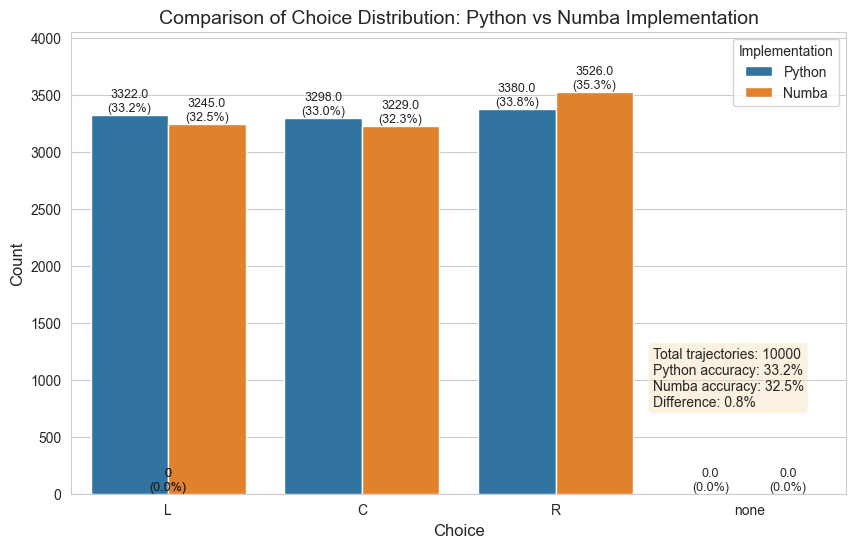

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sim_helpers_fit import simulate_path as simulate_path_py
from sim_helpers_fit_numba import run_trial_numba as simulate_path_nb

# Definición de parámetros
n_trajs = 10000
x0 = np.array([0, 0])
S_base = {'onset': 1.5, 'offset': 2, 'amplitude': 0.1}
U_base = {'onset': 0, 'offset': 2.1, 'amplitude': 2, 'baseline': -1}

U_int_params = U_base
U_ext_params ={'onset': 1.5, 'offset': 2,'amplitude': 0}
S_params = {**S_base, 'd': 0.5}
s_params = {'sL': 0.0, 'sC': 0.0, 'sR': 0.0}
Tmax = 2.1
dt = 0.1 / 40
noise_amp = 0.5
drift = make_drift()
# Simulaciones usando versión Python
choices_py = {'L': 0, 'C': 0, 'R': 0, 'none': 0}
for _ in tqdm(range(n_trajs), desc="Python simulate_path"):
    choice = simulate_path_py('L', S_params, U_int_params, U_ext_params, s_params,drift_fn=drift, noise_amp=noise_amp, Tmax=Tmax, dt=dt)
    choices_py[choice] += 1

# Simulaciones usando versión Numba
choices_nb = {'L': 0, 'C': 0, 'R': 0, 'none': 0}
for _ in tqdm(range(n_trajs), desc="Numba simulate_path"):
    choice = simulate_path_nb('L', S_params, U_int_params, U_ext_params, s_params, Tmax=Tmax, dt=dt, noise_amp=noise_amp)
    choices_nb[choice] += 1

import pandas as pd
results = pd.DataFrame({
    "Choice": ["L", "C", "R", "none"],
    "Python": [choices_py[c] for c in ["L", "C", "R", "none"]],
    "Numba": [choices_nb[c] for c in ["L", "C", "R", "none"]]
})

import seaborn as sns
import matplotlib.pyplot as plt
# Configure plot style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a grouped bar plot comparing Python vs Numba implementation
ax = sns.barplot(x="Choice", y="value", hue="Implementation", 
                 data=pd.melt(results, id_vars=["Choice"], 
                              value_vars=["Python", "Numba"],
                              var_name="Implementation", value_name="value"))

# Add percentage labels to each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = 100 * height / n_trajs
    ax.annotate(f'{height}\n({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height + 5),
                ha='center', va='bottom', fontsize=9)

# Configure plot details
plt.title('Comparison of Choice Distribution: Python vs Numba Implementation', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Choice', fontsize=12)
plt.ylim(0, max(results[["Python", "Numba"]].values.max() * 1.15, 400))


# Add a text box with statistics
stats_text = (f"Total trajectories: {n_trajs}\n"
              f"Python accuracy: {100*choices_py['L']/n_trajs:.1f}%\n"
              f"Numba accuracy: {100*choices_nb['L']/n_trajs:.1f}%\n"
              f"Difference: {abs(100*(choices_py['L']-choices_nb['L'])/n_trajs):.1f}%")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.4)
plt.text(0.75, 0.25, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='center', bbox=props)

end = time.time()

In [3]:
df['ttype_c'].value_counts()/len(df) * 100

ttype_c
DS     38.343401
DM     26.691276
DL     18.212530
VG     15.425333
SIL     1.327460
Name: count, dtype: float64